In [ ]:
import math

board = [" " for _ in range(9)]
minimax_nodes = 0
alphabeta_nodes = 0

def print_board(b):
    print(b[0] + "|" + b[1] + "|" + b[2])
    print("-+-+-")
    print(b[3] + "|" + b[4] + "|" + b[5])
    print("-+-+-")
    print(b[6] + "|" + b[7] + "|" + b[8])
    print()

def check_winner(b, p):
    wins = [(0,1,2),(3,4,5),(6,7,8),(0,3,6),(1,4,7),(2,5,8),(0,4,8),(2,4,6)]
    return any(b[a]==b[b_]==b[c]==p for a,b_,c in wins)

def is_full(b):
    return " " not in b

def minimax(b, is_max):
    global minimax_nodes
    minimax_nodes += 1

    if check_winner(b, "O"):
        return 1
    if check_winner(b, "X"):
        return -1
    if is_full(b):
        return 0

    if is_max:
        best = -math.inf
        for i in range(9):
            if b[i] == " ":
                b[i] = "O"
                best = max(best, minimax(b, False))
                b[i] = " "
        return best
    else:
        best = math.inf
        for i in range(9):
            if b[i] == " ":
                b[i] = "X"
                best = min(best, minimax(b, True))
                b[i] = " "
        return best

def alphabeta(b, is_max, alpha, beta):
    global alphabeta_nodes
    alphabeta_nodes += 1

    if check_winner(b, "O"):
        return 1
    if check_winner(b, "X"):
        return -1
    if is_full(b):
        return 0

    if is_max:
        best = -math.inf
        for i in range(9):
            if b[i] == " ":
                b[i] = "O"
                best = max(best, alphabeta(b, False, alpha, beta))
                b[i] = " "
                alpha = max(alpha, best)
                if beta <= alpha:
                    break
        return best
    else:
        best = math.inf
        for i in range(9):
            if b[i] == " ":
                b[i] = "X"
                best = min(best, alphabeta(b, True, alpha, beta))
                b[i] = " "
                beta = min(beta, best)
                if beta <= alpha:
                    break
        return best

def best_move_minimax(b):
    best_val = -math.inf
    move = -1
    for i in range(9):
        if b[i] == " ":
            b[i] = "O"
            move_val = minimax(b, False)
            b[i] = " "
            if move_val > best_val:
                move = i
                best_val = move_val
    return move

def best_move_alphabeta(b):
    best_val = -math.inf
    move = -1
    for i in range(9):
        if b[i] == " ":
            b[i] = "O"
            move_val = alphabeta(b, False, -math.inf, math.inf)
            b[i] = " "
            if move_val > best_val:
                move = i
                best_val = move_val
    return move

print("Initial Board")
print_board(board)

m1 = best_move_minimax(board)
m2 = best_move_alphabeta(board)

print("Best Move using Minimax:", m1)
print("Nodes explored by Minimax:", minimax_nodes)
print()
print("Best Move using Alpha-Beta:", m2)
print("Nodes explored by Alpha-Beta:", alphabeta_nodes)


Initial Board
 | | 
-+-+-
 | | 
-+-+-
 | | 

Best Move using Minimax: 0
Nodes explored by Minimax: 549945

Best Move using Alpha-Beta: 0
Nodes explored by Alpha-Beta: 30709


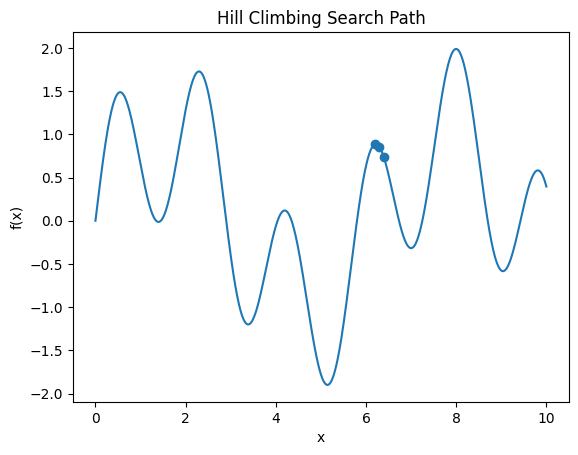

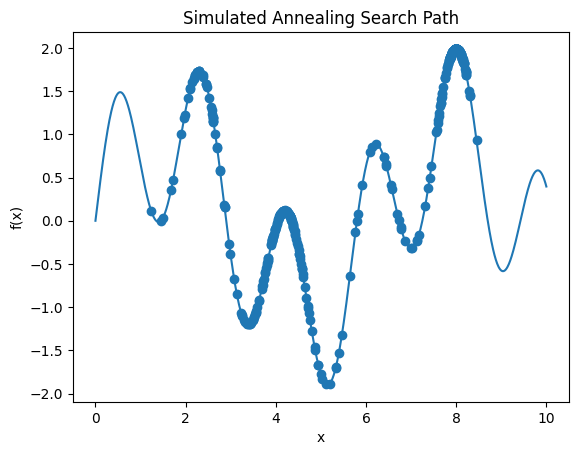

Start Point: 6.394267984578837
Hill Climbing Maximum at x = 6.194267984578838 f(x) = 0.8854989787350303
Simulated Annealing Maximum at x = 7.997109623653962 f(x) = 1.9886934784140744


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random

def f(x):
    return math.sin(x) + math.sin(10*x/3)

xs = np.linspace(0, 10, 1000)
ys = [f(x) for x in xs]

def hill_climbing(start, step=0.1, max_iter=1000):
    x = start
    path = [x]
    for _ in range(max_iter):
        neighbors = [x - step, x + step]
        neighbors = [n for n in neighbors if 0 <= n <= 10]
        next_x = max(neighbors, key=f)
        if f(next_x) <= f(x):
            break
        x = next_x
        path.append(x)
    return x, path

def simulated_annealing(start, temp=10, cooling=0.99, step=0.5, max_iter=1000):
    x = start
    best_x = x
    path = [x]
    for i in range(max_iter):
        T = temp * (cooling ** i)
        if T < 1e-3:
            break
        candidate = x + random.uniform(-step, step)
        candidate = max(0, min(10, candidate))
        delta = f(candidate) - f(x)
        if delta > 0 or random.random() < math.exp(delta / T):
            x = candidate
            path.append(x)
            if f(x) > f(best_x):
                best_x = x
    return best_x, path

random.seed(42)
start_point = random.uniform(0, 10)

hc_max, hc_path = hill_climbing(start_point)
sa_max, sa_path = simulated_annealing(start_point)

plt.figure()
plt.plot(xs, ys)
plt.scatter(hc_path, [f(x) for x in hc_path])
plt.title("Hill Climbing Search Path")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

plt.figure()
plt.plot(xs, ys)
plt.scatter(sa_path, [f(x) for x in sa_path])
plt.title("Simulated Annealing Search Path")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

print("Start Point:", start_point)
print("Hill Climbing Maximum at x =", hc_max, "f(x) =", f(hc_max))
print("Simulated Annealing Maximum at x =", sa_max, "f(x) =", f(sa_max))



In [ ]:
import random

def print_board(b):
    print(b[0] + "|" + b[1] + "|" + b[2])
    print("-+-+-")
    print(b[3] + "|" + b[4] + "|" + b[5])
    print("-+-+-")
    print(b[6] + "|" + b[7] + "|" + b[8])
    print()

def check_winner(b, p):
    wins = [(0,1,2),(3,4,5),(6,7,8),(0,3,6),(1,4,7),(2,5,8),(0,4,8),(2,4,6)]
    return any(b[a]==b[c]==b[d]==p for a,c,d in wins)

def evaluate(b):
    lines = [(0,1,2),(3,4,5),(6,7,8),(0,3,6),(1,4,7),(2,5,8),(0,4,8),(2,4,6)]
    score = 0
    for a,b1,c in lines:
        line = [b[a], b[b1], b[c]]
        if line.count("O") == 3: return 100
        if line.count("X") == 3: return -100
        if line.count("O") == 2 and line.count(" ") == 1: score += 10
        if line.count("X") == 2 and line.count(" ") == 1: score -= 10
        if line.count("O") == 1 and line.count(" ") == 2: score += 1
        if line.count("X") == 1 and line.count(" ") == 2: score -= 1
    return score

def hill_climb_move(board):
    best_score = -999
    best_move = None
    for i in range(9):
        if board[i] == " ":
            board[i] = "O"
            s = evaluate(board)
            board[i] = " "
            if s > best_score:
                best_score = s
                best_move = i
    return best_move

board = [" "] * 9

while True:
    print_board(board)
    move = int(input("Enter your move (0-8): "))
    if board[move] != " ":
        continue
    board[move] = "X"
    if check_winner(board, "X"):
        print_board(board)
        print("You win!")
        break
    if " " not in board:
        print("Draw!")
        break
    ai_move = hill_climb_move(board)
    board[ai_move] = "O"
    if check_winner(board, "O"):
        print_board(board)
        print("AI wins!")
        break
    if " " not in board:
        print("Draw!")
        break


 | | 
-+-+-
 | | 
-+-+-
 | | 

Enter your move (0-8): 1
 |X| 
-+-+-
 |O| 
-+-+-
 | | 

Enter your move (0-8): 7
O|X| 
-+-+-
 |O| 
-+-+-
 |X| 

Enter your move (0-8): 8
O|X| 
-+-+-
 |O| 
-+-+-
O|X|X

Enter your move (0-8): 3
O|X|O
-+-+-
X|O| 
-+-+-
O|X|X

AI wins!


In [ ]:
import random
import math

def simulated_annealing_move(board, temp=10, cooling=0.95):
    moves = [i for i in range(9) if board[i] == " "]
    current = random.choice(moves)
    board[current] = "O"
    current_score = evaluate(board)
    board[current] = " "

    for t in range(1, 50):
        T = temp * (cooling ** t)
        if T < 0.1:
            break
        next_move = random.choice(moves)
        board[next_move] = "O"
        next_score = evaluate(board)
        board[next_move] = " "
        delta = next_score - current_score
        if delta > 0 or random.random() < math.exp(delta / T):
            current = next_move
            current_score = next_score

    return current

board = [" "] * 9

while True:
    print_board(board)
    move = int(input("Enter your move (0-8): "))
    if board[move] != " ":
        continue
    board[move] = "X"
    if check_winner(board, "X"):
        print_board(board)
        print("You win!")
        break
    if " " not in board:
        print("Draw!")
        break
    ai_move = simulated_annealing_move(board)
    board[ai_move] = "O"
    if check_winner(board, "O"):
        print_board(board)
        print("AI wins!")
        break
    if " " not in board:
        print("Draw!")
        break


 | | 
-+-+-
 | | 
-+-+-
 | | 

Enter your move (0-8): 0
X| | 
-+-+-
 | | 
-+-+-
 | |O

Enter your move (0-8): 2
X| |X
-+-+-
 | | 
-+-+-
O| |O

Enter your move (0-8): 1
X|X|X
-+-+-
 | | 
-+-+-
O| |O

You win!


In [ ]:
import random

def print_board(b):
    print("\n")
    print(b[0] + "|" + b[1] + "|" + b[2])
    print("-+-+-")
    print(b[3] + "|" + b[4] + "|" + b[5])
    print("-+-+-")
    print(b[6] + "|" + b[7] + "|" + b[8])
    print("\n")

def winner(b, p):
    wins = [(0,1,2),(3,4,5),(6,7,8),(0,3,6),(1,4,7),(2,5,8),(0,4,8),(2,4,6)]
    return any(b[a]==b[c]==b[d]==p for a,c,d in wins)

def evaluate(b):
    lines = [(0,1,2),(3,4,5),(6,7,8),(0,3,6),(1,4,7),(2,5,8),(0,4,8),(2,4,6)]
    score = 0
    for a,b1,c in lines:
        line = [b[a], b[b1], b[c]]
        if line.count("O") == 3: return 100
        if line.count("X") == 3: return -100
        if line.count("O") == 2 and line.count(" ") == 1: score += 10
        if line.count("X") == 2 and line.count(" ") == 1: score -= 10
        if line.count("O") == 1 and line.count(" ") == 2: score += 1
        if line.count("X") == 1 and line.count(" ") == 2: score -= 1
    return score

def hill_climb_ai(board):
    best_score = -999
    best_move = None
    for i in range(9):
        if board[i] == " ":
            board[i] = "O"
            s = evaluate(board)
            board[i] = " "
            if s > best_score:
                best_score = s
                best_move = i
    return best_move

board = [" "] * 9

while True:
    print_board(board)
    move = int(input("Enter your move (0-8): "))
    if board[move] != " ":
        continue
    board[move] = "X"

    if winner(board, "X"):
        print_board(board)
        print("You win!")
        break

    if " " not in board:
        print("Draw!")
        break

    ai_move = hill_climb_ai(board)
    board[ai_move] = "O"

    if winner(board, "O"):
        print_board(board)
        print("Hill Climbing AI wins!")
        break

    if " " not in board:
        print("Draw!")
        break




 | | 
-+-+-
 | | 
-+-+-
 | | 


Enter your move (0-8): 0


X| | 
-+-+-
 |O| 
-+-+-
 | | 


Enter your move (0-8): 8


X| |O
-+-+-
 |O| 
-+-+-
 | |X


Enter your move (0-8): 6


X| |O
-+-+-
O|O| 
-+-+-
X| |X


Enter your move (0-8): 7


X| |O
-+-+-
O|O| 
-+-+-
X|X|X


You win!


In [ ]:
import random
import math

def simulated_annealing_ai(board, temp=10, cooling=0.95):
    moves = [i for i in range(9) if board[i] == " "]
    current = random.choice(moves)
    board[current] = "O"
    current_score = evaluate(board)
    board[current] = " "

    for t in range(1, 60):
        T = temp * (cooling ** t)
        if T < 0.1:
            break
        candidate = random.choice(moves)
        board[candidate] = "O"
        next_score = evaluate(board)
        board[candidate] = " "
        delta = next_score - current_score
        if delta > 0 or random.random() < math.exp(delta / T):
            current = candidate
            current_score = next_score

    return current

board = [" "] * 9

while True:
    print_board(board)
    move = int(input("Enter your move (0-8): "))
    if board[move] != " ":
        continue
    board[move] = "X"

    if winner(board, "X"):
        print_board(board)
        print("You win!")
        break

    if " " not in board:
        print("Draw!")
        break

    ai_move = simulated_annealing_ai(board)
    board[ai_move] = "O"

    if winner(board, "O"):
        print_board(board)
        print("Simulated Annealing AI wins!")
        break

    if " " not in board:
        print("Draw!")
        break




 | | 
-+-+-
 | | 
-+-+-
 | | 


Enter your move (0-8): 0


X| | 
-+-+-
 | | 
-+-+-
 | |O


Enter your move (0-8): 4


X| |O
-+-+-
 |X| 
-+-+-
 | |O


Enter your move (0-8): 5


X| |O
-+-+-
O|X|X
-+-+-
 | |O


Enter your move (0-8): 5


X| |O
-+-+-
O|X|X
-+-+-
 | |O


Enter your move (0-8): 6


X|O|O
-+-+-
O|X|X
-+-+-
X| |O


Enter your move (0-8): 7
Draw!


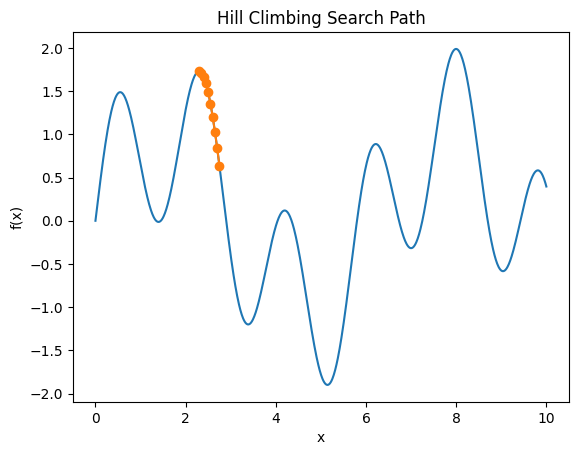

Start: 2.749925919254287
Hill Climbing Maximum at x = 2.2999259192542887 f(x) = 1.7282163406269015


In [ ]:
#2
import numpy as np
import matplotlib.pyplot as plt
import math
import random

def f(x):
    return math.sin(x) + math.sin(10*x/3)

def hill_climbing(start, step=0.05, max_iter=200):
    x = start
    path = [x]
    for _ in range(max_iter):
        left = max(0, x - step)
        right = min(10, x + step)
        best_neighbor = max([left, right], key=f)
        if f(best_neighbor) <= f(x):
            break
        x = best_neighbor
        path.append(x)
    return x, path

xs = np.linspace(0, 10, 1000)
ys = [f(x) for x in xs]

start = random.uniform(0, 10)
max_x, path = hill_climbing(start)

plt.plot(xs, ys)
plt.plot(path, [f(p) for p in path], marker='o')
plt.title("Hill Climbing Search Path")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

print("Start:", start)
print("Hill Climbing Maximum at x =", max_x, "f(x) =", f(max_x))


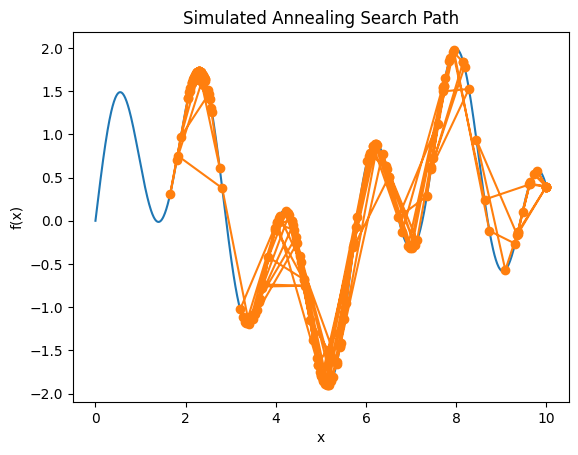

Start: 8.156266544491263
Simulated Annealing Maximum at x = 7.9464026276368624 f(x) = 1.9725956592808145


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random

def f(x):
    return math.sin(x) + math.sin(10*x/3)

def simulated_annealing(start, T0=20, cooling=0.98, max_iter=500):
    x = start
    best_x = x
    path = [x]

    for i in range(max_iter):
        T = T0 * (cooling ** i)
        if T < 1e-3:
            break
        candidate = x + random.uniform(-1, 1)
        candidate = max(0, min(10, candidate))
        delta = f(candidate) - f(x)
        if delta > 0 or random.random() < math.exp(delta / T):
            x = candidate
            path.append(x)
            if f(x) > f(best_x):
                best_x = x
    return best_x, path

xs = np.linspace(0, 10, 1000)
ys = [f(x) for x in xs]

start = random.uniform(0, 10)
max_x, path = simulated_annealing(start)

plt.plot(xs, ys)
plt.plot(path, [f(p) for p in path], marker='o')
plt.title("Simulated Annealing Search Path")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

print("Start:", start)
print("Simulated Annealing Maximum at x =", max_x, "f(x) =", f(max_x))
